# PROJECT 1 - INDIAN ROAD ACCIDENT DATASET - BEGINNER ANALYSIS

## 1. Loading/Understanding the dataset

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\gulbu\Downloads\indian_roads_dataset.csv")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [3]:
df.tail()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10
19999,19999,Delhi,Delhi,28.510266,77.065301,2024-07-05,23:00,23,Friday,0,...,low,39,high,overspeeding,minor,4,2,0,NaN,0.65


## 2. Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [5]:
df.shape

(20000, 24)

In [6]:
df.dtypes

accident_id            int64
city                  object
state                 object
latitude             float64
longitude            float64
date                  object
time                  object
hour                   int64
day_of_week           object
is_weekend             int64
road_type             object
lanes                  int64
traffic_signal         int64
weather               object
visibility            object
temperature            int64
traffic_density       object
cause                 object
accident_severity     object
vehicles_involved      int64
casualties             int64
is_peak_hour           int64
festival              object
risk_score           float64
dtype: object

In [7]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [8]:
df["city"].unique()

array(['Pune', 'Mumbai', 'Chandigarh', 'Chennai', 'Delhi', 'Bangalore',
       'Hyderabad', 'Kolkata'], dtype=object)

In [9]:
df["state"].unique()

array(['Maharashtra', 'Punjab', 'Tamil Nadu', 'Delhi', 'Karnataka',
       'Telangana', 'West Bengal'], dtype=object)

In [10]:
df["day_of_week"].unique()

array(['Sunday', 'Wednesday', 'Thursday', 'Monday', 'Friday', 'Tuesday',
       'Saturday'], dtype=object)

In [11]:
df["road_type"].unique()

array(['highway', 'urban', 'rural'], dtype=object)

In [12]:
df["weather"].unique()

array(['fog', 'clear', 'rain'], dtype=object)

In [13]:
print(df["traffic_density"].unique())
print(df["cause"].unique())
print(df["accident_severity"].unique())

['high' 'low' 'medium']
['weather' 'distraction' 'overspeeding' 'drunk driving' 'poor road']
['fatal' 'major' 'minor']


## 3. Data Cleaning

In [14]:
#duplicates
df = df.drop_duplicates()
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


In [15]:
#droping any column
df = df.drop(columns = ["festival"])
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,fog,low,32,high,weather,fatal,2,2,0,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,clear,high,34,low,weather,major,4,3,0,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,fog,low,21,medium,weather,minor,1,1,0,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,fog,low,30,high,distraction,minor,5,2,0,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,clear,high,24,low,distraction,minor,2,1,0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,clear,high,31,low,distraction,minor,3,2,0,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,clear,high,20,low,distraction,major,4,2,0,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,clear,high,22,low,weather,minor,3,3,0,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,clear,high,33,low,poor road,minor,1,0,0,0.10


In [16]:
#Features
df["date"] = pd.to_datetime(df["date"])
df["time"] = pd.to_datetime(df["time"], format="%H:%M").dt.time

df["is_weekend"] = df["is_weekend"].astype("bool")
df["traffic_signal"] = df["traffic_signal"].astype("bool")
df["is_peak_hour"] = df["is_peak_hour"].astype("bool")

In [17]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00:00,5,Sunday,True,...,fog,low,32,high,weather,fatal,2,2,False,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00:00,4,Sunday,True,...,clear,high,34,low,weather,major,4,3,False,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00:00,13,Wednesday,False,...,fog,low,21,medium,weather,minor,1,1,False,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00:00,11,Sunday,True,...,fog,low,30,high,distraction,minor,5,2,False,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00:00,16,Thursday,False,...,clear,high,24,low,distraction,minor,2,1,False,0.10


In [18]:
category_columns = [
    "city", "state", "road_type", "weather",
    "visibility", "traffic_density", "cause",
    "accident_severity", "day_of_week"
]

for col in category_columns:
    df[col] = df[col].astype("category")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   accident_id        20000 non-null  int64         
 1   city               20000 non-null  category      
 2   state              20000 non-null  category      
 3   latitude           20000 non-null  float64       
 4   longitude          20000 non-null  float64       
 5   date               20000 non-null  datetime64[ns]
 6   time               20000 non-null  object        
 7   hour               20000 non-null  int64         
 8   day_of_week        20000 non-null  category      
 9   is_weekend         20000 non-null  bool          
 10  road_type          20000 non-null  category      
 11  lanes              20000 non-null  int64         
 12  traffic_signal     20000 non-null  bool          
 13  weather            20000 non-null  category      
 14  visibi

In [20]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00:00,5,Sunday,True,...,fog,low,32,high,weather,fatal,2,2,False,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00:00,4,Sunday,True,...,clear,high,34,low,weather,major,4,3,False,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00:00,13,Wednesday,False,...,fog,low,21,medium,weather,minor,1,1,False,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00:00,11,Sunday,True,...,fog,low,30,high,distraction,minor,5,2,False,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00:00,16,Thursday,False,...,clear,high,24,low,distraction,minor,2,1,False,0.10


## 4. EDA

In [21]:
df.describe()

,accident_id,latitude,longitude,date,hour,lanes,temperature,vehicles_involved,casualties,risk_score
count,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,2023-08-22 07:04:48.000000256,11.487200,3.493950,27.579600,2.992000,1.726450,0.437585
min,0.000000,12.800172,72.700017,2022-01-01 00:00:00,0.000000,1.000000,15.000000,1.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,2022-10-25 00:00:00,5.000000,2.000000,21.000000,2.000000,1.000000,0.250000
50%,9999.500000,18.812008,77.297000,2023-08-21 00:00:00,12.000000,4.000000,28.000000,3.000000,1.000000,0.450000
75%,14999.250000,28.402467,80.111089,2024-06-21 00:00:00,18.000000,5.000000,34.000000,4.000000,3.000000,0.600000
max,19999.000000,30.799960,88.499861,2025-04-15 00:00:00,23.000000,6.000000,40.000000,5.000000,5.000000,1.000000
std,5773.647028,6.165791,4.485967,NaN,6.945563,1.705406,7.454746,1.415534,1.489104,0.218130


<Axes: xlabel='accident_severity', ylabel='risk_score'>

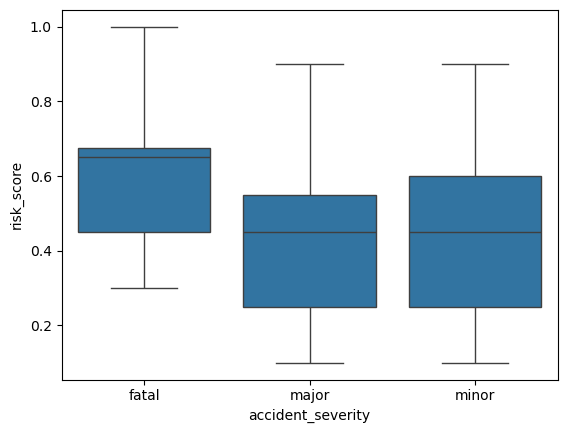

In [23]:
sns.boxplot(x="accident_severity", y="risk_score", data=df)

In [57]:
#INSIGHT: Higher accident severity levels are associated with higher median risk scores. Fatal accidents tend to occur under higher-risk conditions.

In [24]:
#categorical variables
category_columns = df.select_dtypes(include = ["category"]).columns

for col in category_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


city
city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

state
state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Delhi          2433
Telangana      2409
Name: count, dtype: int64

day_of_week
day_of_week
Monday       2966
Friday       2879
Tuesday      2871
Saturday     2867
Sunday       2856
Thursday     2835
Wednesday    2726
Name: count, dtype: int64

road_type
road_type
urban      6745
rural      6639
highway    6616
Name: count, dtype: int64

weather
weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64

visibility
visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

traffic_density
traffic_density
low       7067
high      7034
medium    5899
Name: count, dtype: int64

cause
cause
distraction      4026
overspeeding     4025
weather          399

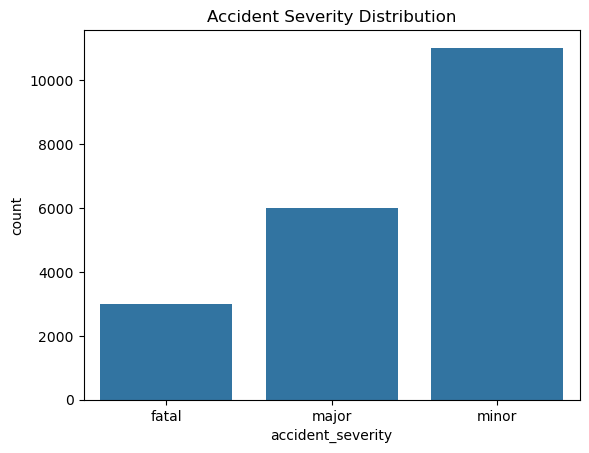

In [25]:
#accident_severity - distribution
sns.countplot(x = "accident_severity", data = df)
plt.title("Accident Severity Distribution")
plt.show()

In [45]:
#Insight:The dataset shows that most accidents are classified as minor, followed by major and fatal accidents. This indicates that while accidents are frequent, the majority do not result in severe consequences. However, the presence of a significant number of major and fatal cases highlights the importance of identifying high-risk conditions.

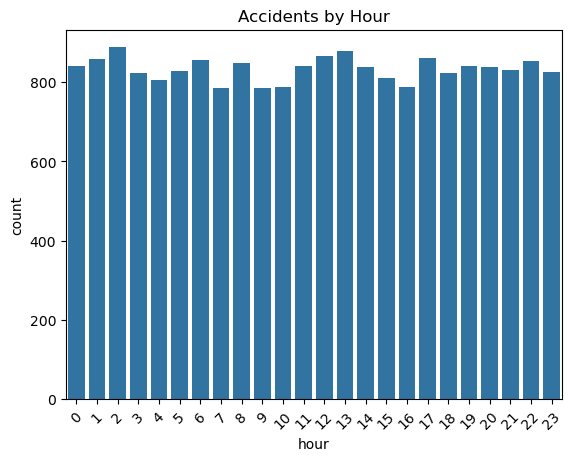

In [26]:
#Time series analysis

#Accidents based on hours
sns.countplot(x = "hour", data = df)
plt.title("Accidents by Hour")
plt.xticks(rotation = 45)
plt.show()

In [46]:
#INSIGHT:Accidents tend to increase during peak traffic hours, especially in the morning and evening. This suggests that higher traffic density and congestion during these hours contribute to a higher likelihood of accidents.

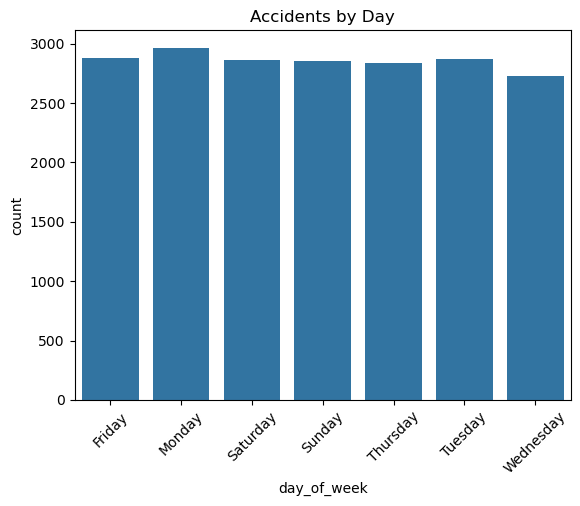

In [27]:
#based on days
sns.countplot(x = "day_of_week", data = df)
plt.title("Accidents by Day")
plt.xticks(rotation = 45)
plt.show()

In [49]:
#INSIGHT:Accident frequency appears relatively consistent across the week, with slight variations. Nevertheless, Monday appears to be the day with the highest accidents.

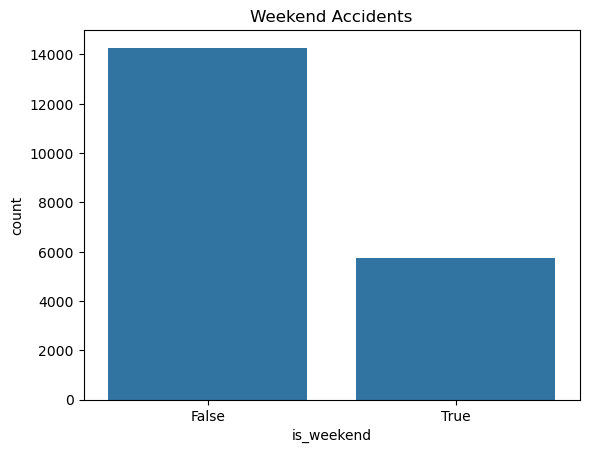

In [28]:
#weekend effect
sns.countplot(x = "is_weekend", data = df)
plt.title("Weekend Accidents")
plt.show()

In [48]:
#INSIGHT: The number of accidents is higher on weekdays than on weekends, which may be due to most people working.

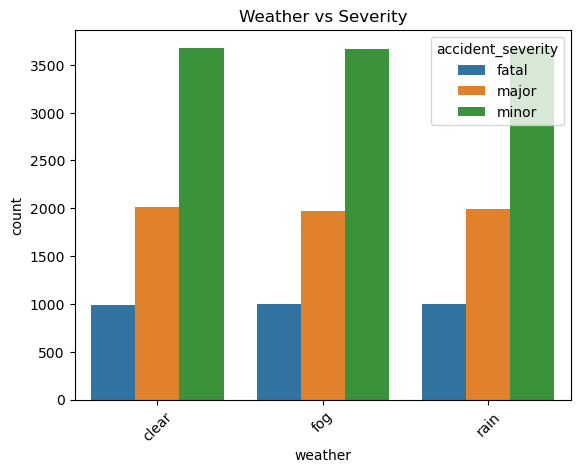

In [29]:
#Environment Analysis

#Weather effect
sns.countplot(x = "weather", hue = "accident_severity", data = df)
plt.title("Weather vs Severity")
plt.xticks(rotation = 45)
plt.show()

In [50]:
#INSIGHT: It appears that accidents do not vary according to weather conditions, and the number of accidents remains the same under three different weather conditions.

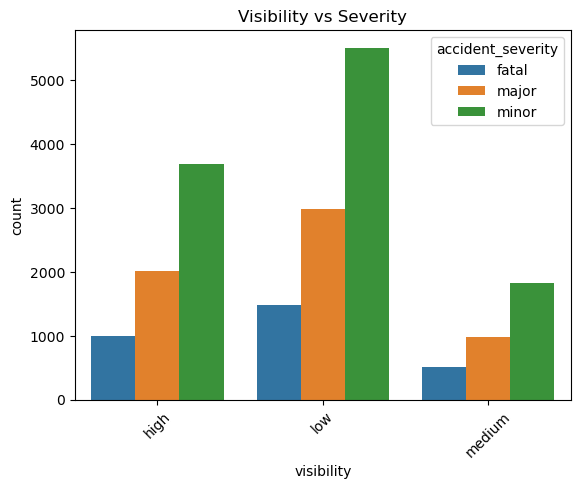

In [30]:
#visibility effect
sns.countplot(x = "visibility", hue = "accident_severity", data = df)
plt.title("Visibility vs Severity")
plt.xticks(rotation = 45)
plt.show()

In [51]:
#INSIGHT:Lower visibility conditions are associated with a higher proportion of severe accidents, while medium visibility conditions are associated with at least.

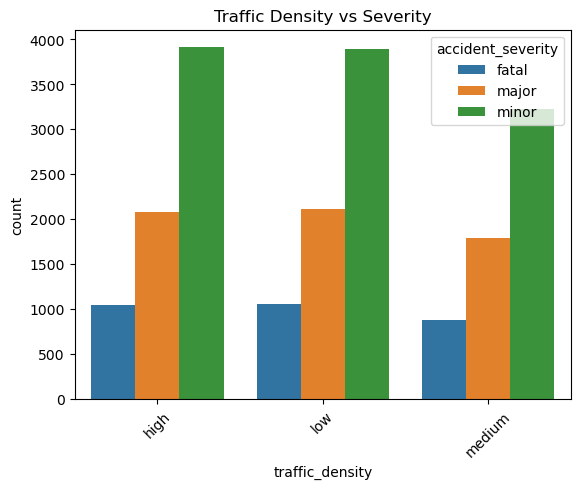

In [31]:
#Traffic & Road Analysis

#Traffic Density
sns.countplot(x="traffic_density", hue="accident_severity", data=df)
plt.title("Traffic Density vs Severity")
plt.xticks(rotation=45)
plt.show()

In [52]:
#INSIGHT:Although higher traffic density increases the number of accidents, it does not significantly increase accident severity.

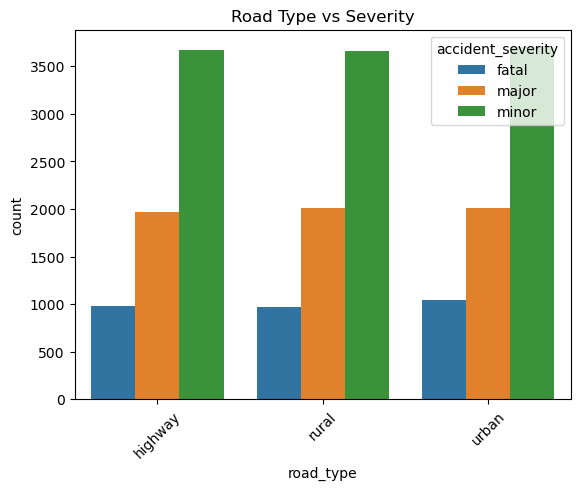

In [32]:
#Road type
sns.countplot(x="road_type", hue="accident_severity", data=df)
plt.title("Road Type vs Severity")
plt.xticks(rotation=45)
plt.show()

In [53]:
#INSIGHT: There is no significant difference between road type accident counts.

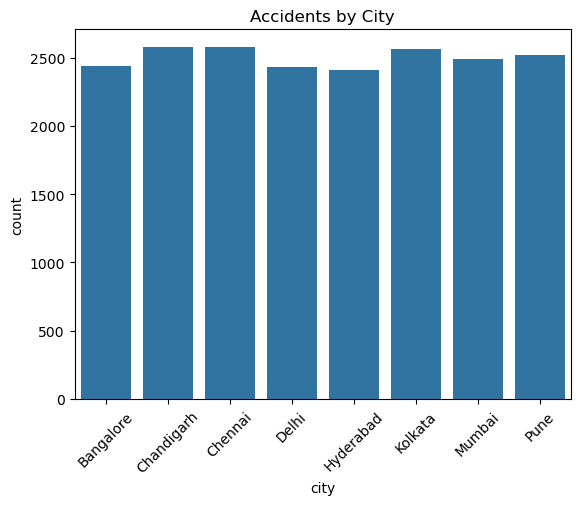

In [33]:
#City Analysis
sns.countplot(x="city", data=df)
plt.title("Accidents by City")
plt.xticks(rotation=45)
plt.show()

In [54]:
#INSIGHT: Compared to other cities, there are 3 cities that stand out in terms of the number of accidents: Chandigarh, Chennai and Kolkata.

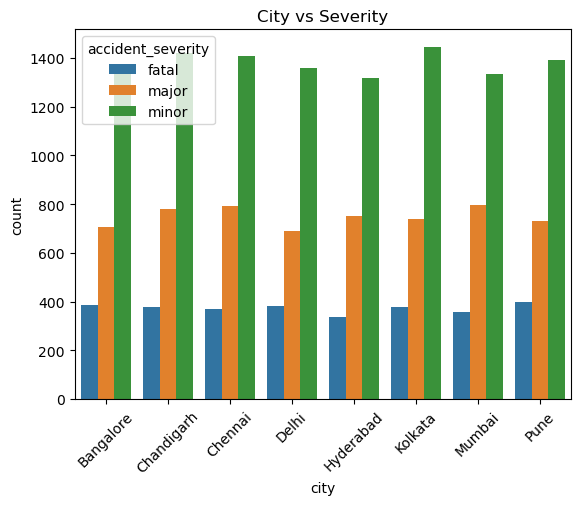

In [34]:
#Severity vs City
sns.countplot(x="city", hue="accident_severity", data=df)
plt.xticks(rotation=45)
plt.title("City vs Severity")
plt.show()

In [55]:
#INSIGHT: Some cities show a higher proportion of severe accidents, suggesting that local factors such as road conditions, traffic behavior, or infrastructure quality may impact accident outcomes.

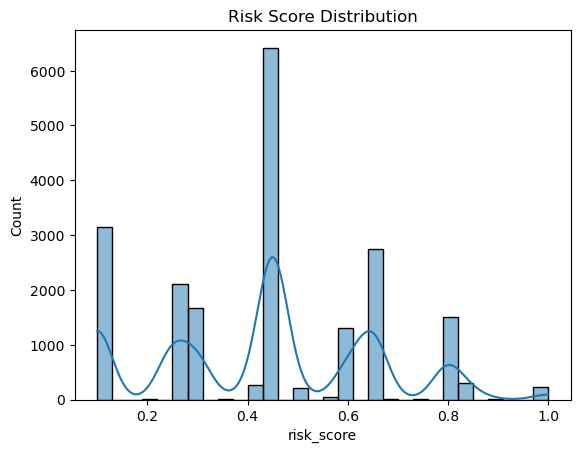

In [35]:
#Numeric Analysis
sns.histplot(df["risk_score"], bins=30, kde=True)
plt.title("Risk Score Distribution")
plt.show()

In [56]:
#INSIGHT: Risk scores are distributed across a wide range, indicating variability in accident conditions. Higher risk scores are associated with more dangerous driving environments.

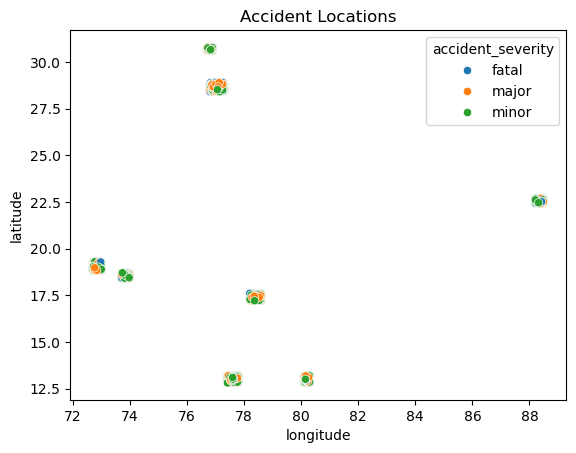

In [36]:
#Location
sns.scatterplot(x="longitude", y="latitude", hue="accident_severity", data=df)
plt.title("Accident Locations")
plt.show()

## 5. Analysis

In [37]:
#Business Problem: At what times do accidents increase?
df.groupby("hour")["casualties"].mean()

hour
0     1.734524
1     1.734575
2     1.659910
3     1.834951
4     1.698137
5     1.665054
6     1.775701
7     1.760814
8     1.681979
9     1.707379
10    1.735108
11    1.680143
12    1.831409
13    1.660592
14    1.704057
15    1.789149
16    1.843710
17    1.708479
18    1.766707
19    1.819048
20    1.687351
21    1.649398
22    1.640094
23    1.681212
Name: casualties, dtype: float64

In [38]:
#Business Problem: Does the weather affect the accident?
pd.crosstab(df["weather"], df["accident_severity"], normalize = "index")

accident_severity,fatal,major,minor
weather,,,
clear,0.148281,0.301495,0.550224
fog,0.150008,0.297754,0.552239
rain,0.149768,0.298937,0.551295


In [39]:
#Business Problem: Is traffic congestion a factor?
pd.crosstab(df["traffic_density"], df["accident_severity"], normalize="index")

accident_severity,fatal,major,minor
traffic_density,,,
high,0.148564,0.295280,0.556156
low,0.150134,0.299420,0.550446
medium,0.149347,0.304289,0.546364


In [40]:
#Business Problem: Which city is riskier?
df.groupby("city")["risk_score"].mean().sort_values(ascending=False)

C:\Users\gulbu\AppData\Local\Temp\ipykernel_6048\3323926944.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("city")["risk_score"].mean().sort_values(ascending=False)


city
Chandigarh    0.441618
Bangalore     0.440217
Hyderabad     0.439456
Chennai       0.437573
Delhi         0.437115
Pune          0.435836
Kolkata       0.434584
Mumbai        0.434350
Name: risk_score, dtype: float64

<Axes: xlabel='accident_severity', ylabel='casualties'>

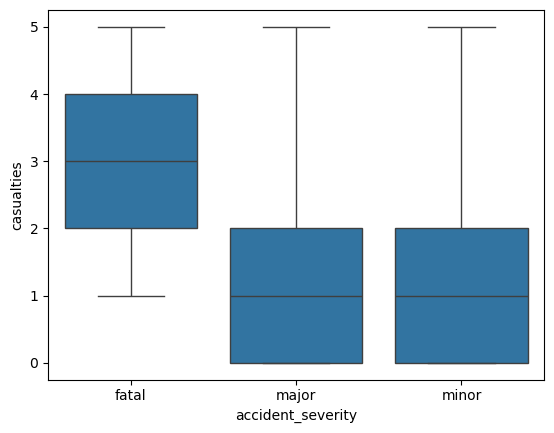

In [41]:
sns.boxplot(x="accident_severity", y="casualties", data=df)

In [59]:
#INSIGHT: Higher severity levels are associated with a greater number of casualties. Fatal accidents show significantly higher casualty counts, while major and minor is almost the same.

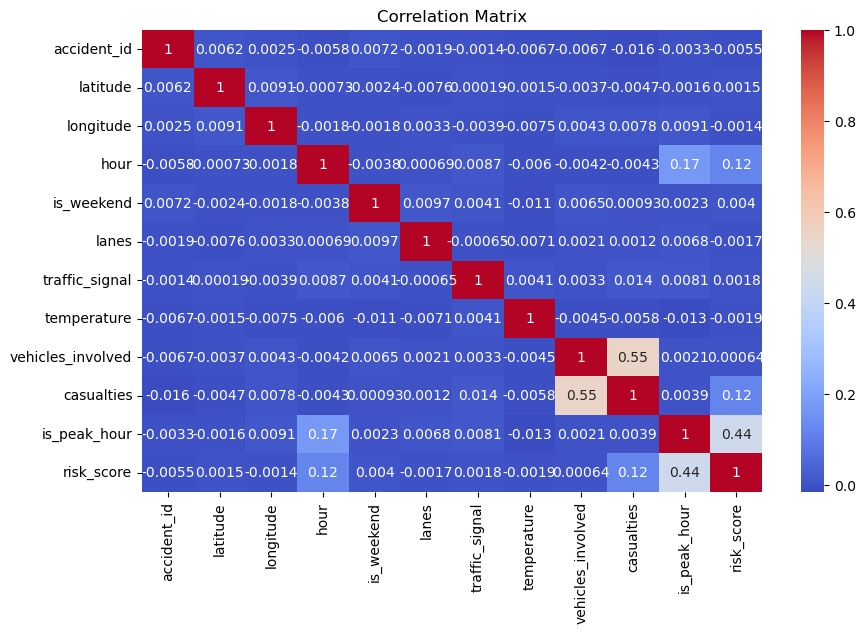

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [58]:
#INSIGHT: Risk score and casualties show a positive relationship, indicating that more dangerous conditions tend to result in more severe outcomes. However, most variables show low correlation, suggesting that accident severity is influenced by a combination of multiple factors rather than a single dominant variable.

In [60]:
df.groupby(["weather", "traffic_density"])["risk_score"].mean()

C:\Users\gulbu\AppData\Local\Temp\ipykernel_6048\690489901.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["weather", "traffic_density"])["risk_score"].mean()


weather  traffic_density
clear    high               0.393806
         low                0.140000
         medium             0.167534
fog      high               0.745941
         low                0.490363
         medium             0.520941
rain     high               0.644841
         low                0.392062
         medium             0.414203
Name: risk_score, dtype: float64

In [63]:
#INSIGHT: The average risk rate is highest when the weather is foggy and traffic density is high.

In [65]:
high_risk = df.sort_values(by="risk_score", ascending = False).head(10)
high_risk

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
9003,9003,Pune,Maharashtra,18.561304,73.701937,2023-11-19,10:00:00,10,Sunday,True,...,fog,low,38,high,drunk driving,fatal,3,3,True,1.0
8560,8560,Hyderabad,Telangana,17.583400,78.577584,2024-08-28,08:00:00,8,Wednesday,False,...,fog,low,26,high,weather,fatal,5,5,True,1.0
9370,9370,Chandigarh,Punjab,30.727081,76.882594,2024-07-29,09:00:00,9,Monday,False,...,fog,low,37,high,drunk driving,fatal,2,2,True,1.0
9345,9345,Pune,Maharashtra,18.664453,73.891091,2024-08-12,18:00:00,18,Monday,False,...,rain,low,16,high,distraction,fatal,4,4,True,1.0
9330,9330,Delhi,Delhi,28.706631,77.231170,2023-12-26,18:00:00,18,Tuesday,False,...,fog,low,31,high,poor road,fatal,1,1,True,1.0
1122,1122,Pune,Maharashtra,18.563073,73.957050,2023-11-29,18:00:00,18,Wednesday,False,...,fog,low,26,high,distraction,fatal,3,3,True,1.0
17744,17744,Kolkata,West Bengal,22.578337,88.347896,2022-11-05,08:00:00,8,Saturday,True,...,rain,low,27,high,overspeeding,fatal,2,2,True,1.0
17763,17763,Mumbai,Maharashtra,19.286255,72.984526,2023-02-21,18:00:00,18,Tuesday,False,...,fog,low,30,high,weather,fatal,5,5,True,1.0
9195,9195,Hyderabad,Telangana,17.350975,78.282446,2025-03-27,10:00:00,10,Thursday,False,...,rain,low,28,high,poor road,fatal,4,4,True,1.0
9141,9141,Delhi,Delhi,28.773983,77.023514,2023-12-19,19:00:00,19,Tuesday,False,...,rain,low,22,high,poor road,fatal,5,5,True,1.0


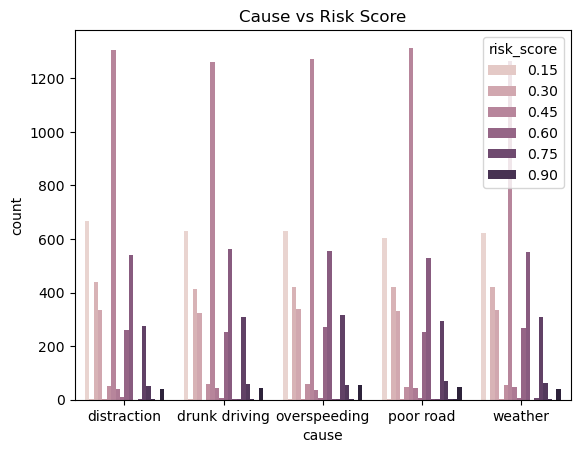

In [69]:
#Cause vs Risk score
sns.countplot(x="cause", hue="risk_score", data=df)
plt.title("Cause vs Risk Score")
plt.show()

In [72]:
df.groupby(["day_of_week", "hour"])["risk_score"].mean().sort_values(ascending=False)

C:\Users\gulbu\AppData\Local\Temp\ipykernel_6048\265179341.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["day_of_week", "hour"])["risk_score"].mean().sort_values(ascending=False)


day_of_week  hour
Wednesday    17      0.634375
Monday       18      0.634252
Saturday     10      0.632328
             8       0.630992
Monday       10      0.630374
                       ...   
Saturday     3       0.332645
Wednesday    0       0.332377
Tuesday      0       0.328571
Friday       3       0.325877
Sunday       2       0.322650
Name: risk_score, Length: 168, dtype: float64

In [73]:
#INSIGHT: high risk times: Wednesday 17:00 and Monday 18:00